In [2]:
from google.colab import drive
drive.mount('/content/drive')

# 코랩 konlpy 실행
!curl -s https://raw.githubusercontent.com/teddylee777/machine-learning/master/99-Misc/01-Colab/mecab-colab.sh | bash

# Mecab 설치 후 Google Drive에 복사
!cp -r /usr/local/lib/mecab /content/drive/MyDrive/mecab
!cp -r /usr/local/etc/mecabrc /content/drive/MyDrive/mecab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--2026-06-01 06:30:28--  https://www.dropbox.com/s/9xls0tgtf3edgns/mecab-0.996-ko-0.9.2.tar.gz?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/g8l6dlu5a3ebovcdymluq/mecab-0.996-ko-0.9.2.tar.gz?rlkey=xlooryouhr1l2ufqbt93ohfvy&dl=1 [following]
--2026-06-01 06:30:28--  https://www.dropbox.com/scl/fi/g8l6dlu5a3ebovcdymluq/mecab-0.996-ko-0.9.2.tar.gz?rlkey=xlooryouhr1l2ufqbt93ohfvy&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5f7cc89ea9165a8693bd689dea.dl.dropboxusercontent.com/cd/0/inline/DBiF06wTiB80cDQDkCsoxH3FTZST_HIjeU331Vtrs1a7ZJj4eBkolIxaWfYnBva07Mr5LbKu0Lzef6zFlnT

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
from konlpy.tag import Okt
from collections import Counter
import re

In [5]:
import pickle

# 파일이 저장된 경로를 입력하세요. (예: 'my_data.pkl')
file_path = '/content/drive/MyDrive/DX PROJ./임베딩/전체데이터.pkl'

# 'rb'는 읽기(read) 및 바이너리(binary) 모드를 의미합니다.
with open(file_path, 'rb') as file:
    df = pickle.load(file)

# 불러온 데이터 확인
df.head()

,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens,sub_cluster
0,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"[서대구역, 구역, 들다, 단지, 정확하다, 모르다, 부실, 공사, 값, 평가, 아...","[-0.14360012114048004, -0.005446251481771469, ...",2,서대구역 구역 들다 단지 정확하다 모르다 부실 공사 값 평가 되다 아파트 맞다,서대구역 구역 들다 단지 정확하다 모르다 부실 공사 값 평가 아파트 맞다,0
1,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"[정신병, 이웃, 난, 불다, 조현병, 같다, 두다]","[-0.8485231399536133, -0.4335775673389435, 0.0...",2,정신병 이웃 난 불다 조현병 같다 두다,정신병 이웃 난 불다 조현병 같다 두다,1
2,NaN,인간이길 포기한 숨쉬며 꿈틀꿈틀 움직이는 물체는 폐기처분 합시다 자꾸 이런저런 이유...,"[인간, 이기다, 포기, 숨쉬다, 움직이다, 물체, 폐기, 처분, 자꾸, 이유, 비...","[-0.16455712914466858, -0.4579088091850281, 0....",2,인간 이기다 포기 숨쉬다 움직이다 물체 폐기 처분 하다 자꾸 이유 보다 비극 사건 ...,인간 이기다 포기 숨쉬다 움직이다 물체 폐기 처분 자꾸 이유 비극 사건 남무 세상 ...,1
3,NaN,꼴통이아래집에살고있으니 노답이네 조현병은불치병이라 완치안돼 정신병자라 더잔인함 절대...,"[꼴통, 아래, 집, 살다, 노답, 조현병, 불치, 병, 완치, 돼다, 정신병, 자...","[-0.9262545704841614, -0.2466546893119812, 0.2...",2,꼴통 아래 집 살다 노답 조현병 불치 병 완치 돼다 정신병 자라 잔인함 절대로 근처...,꼴통 아래 집 살다 노답 조현병 불치 병 완치 돼다 정신병 자라 잔인함 절대로 근처...,1
4,NaN,저런거는 섬에 가두고 먹을꺼주지말고 던저놓자 돌아가신분이 무슨 죄냐 안타깝습니다 대...,"[저러다, 섬, 가두다, 먹다, 던저, 놓다, 돌아가다, 신분, 무슨, 죄, 안타깝...","[0.08430330455303192, -0.5858102440834045, 0.0...",2,저러다 섬 가두다 먹다 던저 놓다 돌아가다 신분 무슨 죄 안타깝다 살 있다 독하다 독해,저러다 섬 가두다 먹다 던저 놓다 돌아가다 신분 무슨 죄 안타깝다 살 독하다 독해,1


In [8]:
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv

# 2. 설치 후 반드시 '런타임 다시 시작'을 해야 합니다.
# 상단 메뉴: 런타임 > 런타임 다시 시작

# 3. 런타임 재시작 후 아래 설정 코드를 실행
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (44.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/s

In [9]:
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv

# 2. 설치 후 반드시 '런타임 다시 시작'을 해야 합니다.
# 상단 메뉴: 런타임 > 런타임 다시 시작

# 3. 런타임 재시작 후 아래 설정 코드를 실행
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [7]:
# 1. 지우고 싶은 단어 목록 정의
words_to_remove = ['하다', '있다']

# 2. 데이터프레임에서 해당 단어들을 제거 (iyusik_df 기준)
df['token'] = df['token'].apply(
    lambda x: [word for word in x if word not in words_to_remove] if isinstance(x, list) else x
)

# 3. (확인용) 잘 제거되었는지 상위 토큰 확인
print("단어 제거 완료!")

단어 제거 완료!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 65.6 MB/s eta 0:00:00


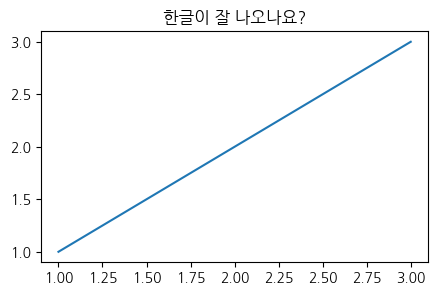

In [9]:
# 1. 라이브러리 설치
!pip install koreanize-matplotlib

# 2. 라이브러리 임포트 (이것만 하면 설정 끝!)
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 테스트용 그래프
plt.figure(figsize=(5,3))
plt.title("한글이 잘 나오나요?")
plt.plot([1, 2, 3], [1, 2, 3])
plt.show()

In [25]:
# 1. 지우고 싶은 단어 목록 정의
words_to_remove = ['하다', '있다', '거','같다','본문','수집','실패','지다','들다','이다','요','줄','감사','드리다','분','먹다','재생','키우다', '사','건설','내다','또','추천']

# 2. 데이터프레임에서 해당 단어들을 제거 (iyusik_df 기준)
df['token'] = df['token'].apply(
    lambda x: [word for word in x if word not in words_to_remove] if isinstance(x, list) else x
)

# 3. (확인용) 잘 제거되었는지 상위 토큰 확인
print("단어 제거 완료!")

단어 제거 완료!


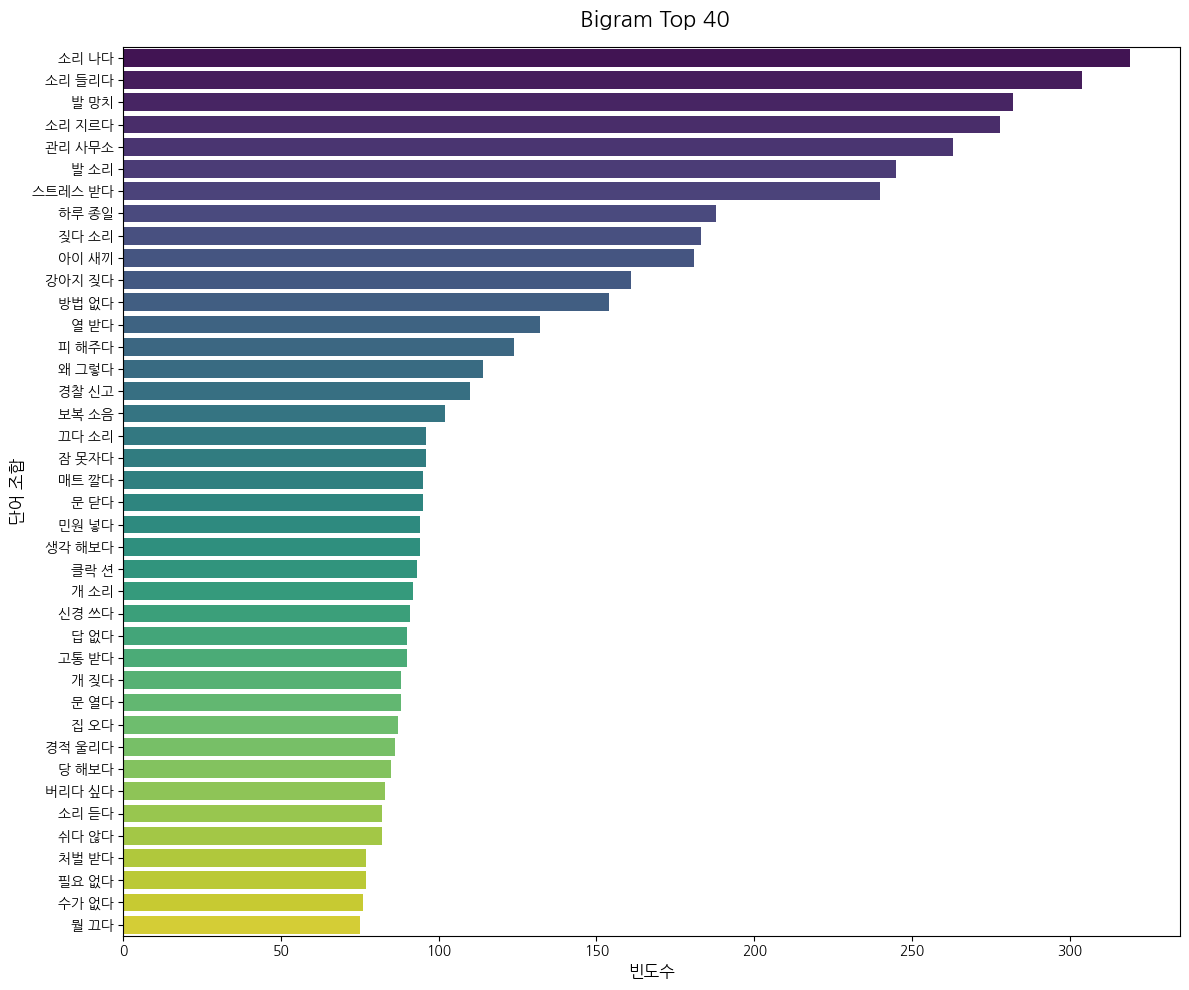

In [26]:
# 1. 미싱 링크: get_ngram_counts 함수 정의하기
def get_ngram_counts(token_col, n=2):
    all_ngrams = []
    for token_list in token_col:
        # 리스트 형태가 맞고 단어 개수가 n개 이상일 때만 n-gram 생성
        if isinstance(token_list, list) and len(token_list) >= n:
            # ngrams의 결과는 튜플 형태이므로 리스트에 추가
            all_ngrams.extend(list(ngrams(token_list, n)))

    # Counter 객체로 변환하여 반환
    return Counter(all_ngrams)

# 2. 시각화 함수 정의
def plot_top_ngrams(counter, title, top_n=40):
    most_common = counter.most_common(top_n)

    # 튜플 형태의 빅램 ('하다', '행위')을 '하다 행위' 형태의 문자열로 결합
    labels = [" ".join(item[0]) for item in most_common]
    counts = [item[1] for item in most_common]

    plt.figure(figsize=(12, 10)) # 40개나 보여주므로 세로 길이를 조금 늘렸습니다 (8 -> 10)
    sns.barplot(x=counts, y=labels, palette='viridis')

    plt.title(title, fontsize=16, pad=15)
    plt.xlabel('빈도수', fontsize=12)
    plt.ylabel('단어 조합', fontsize=12)
    plt.tight_layout()
    plt.show()

# 3. 빅램 분석 및 시각화 실행 예시
# (주의: 이전에 df['cleaned_token'] 데이터 정제가 완료된 상태여야 합니다!)
bigram_counts = get_ngram_counts(df['token'], n=2)
plot_top_ngrams(bigram_counts, " Bigram Top 40")